In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynwb import NWBHDF5IO
from scipy.signal import find_peaks

In [17]:
path = "data/AO026_20181122_180943.nwb"
THIS_AREA = "wS1"

with NWBHDF5IO(path, "r") as io:
    nwb = io.read()
    tr = nwb.trials.to_dataframe().copy()
    areas = nwb.units["Target_area"].data[:]
    areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])
    unit_mask = (areas == THIS_AREA)

    spike_times = []
    for i in np.where(unit_mask)[0]:
        st = nwb.units["spike_times"][i]
        spike_times.append(np.asarray(st))

print("Number of selected units:", len(spike_times))
print("Example spike train length:", len(spike_times[0]))
print("First 10 spikes:", spike_times[0][:10])
print("Total trials:", len(tr))
print("Stim trials:", tr["whisker_stim"].sum())
print("Catch trials:", tr["no_stim"].sum())

Number of selected units: 30
Example spike train length: 2727
First 10 spikes: [4.14076667 4.1556     4.47973333 4.48993333 6.58133333 6.61876667
 6.63066667 6.78743333 6.8086     6.86803333]
Total trials: 289
Stim trials: 146
Catch trials: 143


In [18]:
Bin_size = 0.01
AP_Bin_Resolution = 1.0 / Bin_size

duration = float(tr["stop_time"].max())
n_bins = int(np.round(duration * AP_Bin_Resolution))
edges = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)

AP_Bin_Matrx = np.zeros((len(spike_times), n_bins), dtype=np.float32)

for n, st in enumerate(spike_times):
    counts, _ = np.histogram(st, bins=edges)
    AP_Bin_Matrx[n, :] = counts

Mean_Pop_Act = AP_Bin_Matrx.mean(axis=0)

print("Total spikes in AP:", AP_Bin_Matrx.sum())

Total spikes in AP: 431640.0


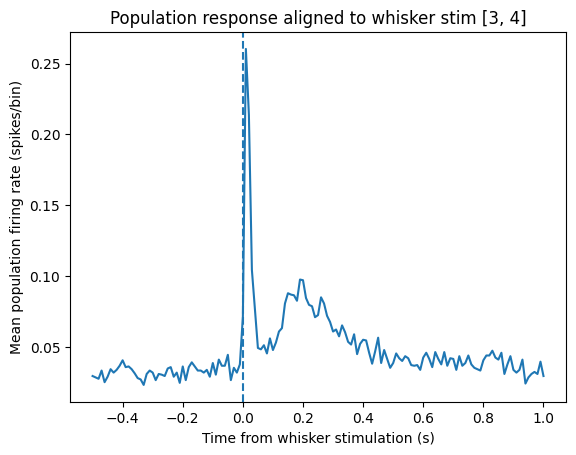

In [ ]:
# function to plot mean of population of different stimulus amplitude
def plot_population_response(tr, amps=[3, 4]):
    selection = (tr["whisker_stim_amplitude"].isin(amps)) & tr["whisker_stim_time"].notna()
    Whisker_Stim_times_H = np.sort((tr.loc[selection, "whisker_stim_time"]).to_numpy())

    # STM_MTRX = np.zeros((len(Whisker_Stim_times_H), 151), dtype=np.float32)
    STM_MTRX = np.full((len(Whisker_Stim_times_H), 151), np.nan, dtype=np.float32)

    for t, ev in enumerate(Whisker_Stim_times_H):
        this_stim_pt = int(np.round(ev * AP_Bin_Resolution))
        pt1 = this_stim_pt - 50
        pt2 = this_stim_pt + 100
        if pt1 < 0 or pt2 >= Mean_Pop_Act.shape[0]:
            continue
        STM_MTRX[t, :] = Mean_Pop_Act[pt1:pt2+1]

    Stim_avg = np.nanmean(STM_MTRX, axis=0)

    # time axis in seconds
    time_axis = (np.arange(151) - 50) * Bin_size

    plt.figure()
    plt.plot(time_axis, Stim_avg)

    plt.axvline(0, linestyle="--")  # temps 0 = stimulation
    plt.xlabel("Time from whisker stimulation (s)")
    plt.ylabel("Mean population firing rate (spikes/bin)")
    plt.title(f"Population response aligned to whisker stim {amps}")
    plt.show()

plot_population_response(tr)

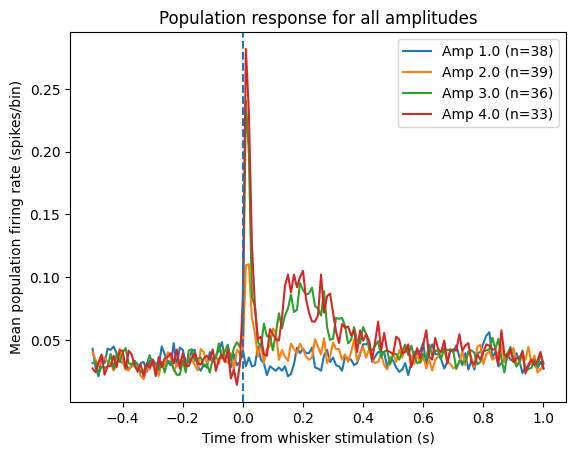

In [41]:
# function to see all amplitudes together
def plot_population_response_all_amps(tr):
    amps_unique = sorted(tr["whisker_stim_amplitude"].dropna().unique())

    time_axis = (np.arange(151) - 50) * Bin_size

    plt.figure()

    for amp in amps_unique:
        selection = (
            (tr["whisker_stim_amplitude"] == amp) &
            tr["whisker_stim_time"].notna()
        )

        Whisker_times = np.sort(
            tr.loc[selection, "whisker_stim_time"].to_numpy()
        )

        if len(Whisker_times) == 0:
            continue

        STM_MTRX = np.full((len(Whisker_times), 151), np.nan, dtype=np.float32)

        valid = 0
        for t, ev in enumerate(Whisker_times):
            this_stim_pt = int(np.round(ev * AP_Bin_Resolution))
            pt1 = this_stim_pt - 50
            pt2 = this_stim_pt + 100
            if pt1 < 0 or pt2 >= Mean_Pop_Act.shape[0]:
                continue
            STM_MTRX[t, :] = Mean_Pop_Act[pt1:pt2+1]
            valid += 1

        if valid == 0:
            continue

        Stim_avg = np.nanmean(STM_MTRX, axis=0)

        plt.plot(time_axis, Stim_avg, label=f"Amp {amp} (n={valid})")

    plt.axvline(0, linestyle="--")
    plt.xlabel("Time from whisker stimulation (s)")
    plt.ylabel("Mean population firing rate (spikes/bin)")
    plt.title("Population response for all amplitudes")
    plt.legend()
    plt.show()

plot_population_response_all_amps(tr)

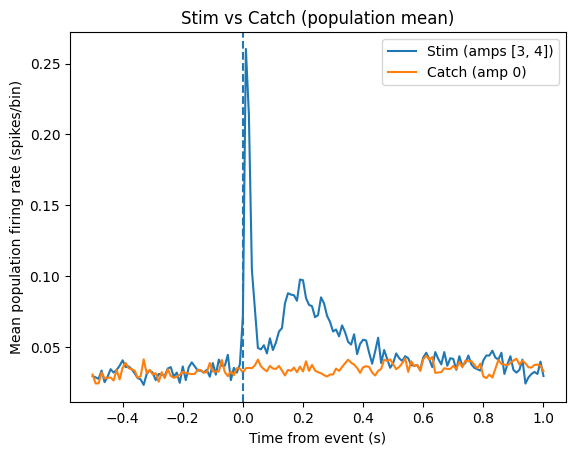

In [45]:
amps_stim = [3, 4]
amp_catch = 0

# Filtering
stim_sel = tr["whisker_stim_amplitude"].isin(amps_stim) & tr["whisker_stim_time"].notna()
Whisker_Stim_times_H = np.sort(tr.loc[stim_sel, "whisker_stim_time"].to_numpy())

catch_sel = tr["no_stim"].astype(bool) & tr["no_stim_time"].notna()
Catch_times = np.sort((tr.loc[catch_sel, "no_stim_time"]).to_numpy())

# Matrix
STM_MTRX = np.zeros((AP_Bin_Matrx.shape[0], 151), dtype=np.float32)
n_valid_stim = 0
for ev in Whisker_Stim_times_H:
    this_stim_pt = int(np.round(ev * AP_Bin_Resolution))
    pt1 = this_stim_pt - 50
    pt2 = this_stim_pt + 100
    if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
        continue
    STM_MTRX += AP_Bin_Matrx[:, pt1:pt2+1]
    n_valid_stim += 1
STM_MTRX /= max(n_valid_stim, 1)

CATCH_MTRX = np.zeros((AP_Bin_Matrx.shape[0], 151), dtype=np.float32)
n_valid_catch = 0
for ev in Catch_times:
    this_stim_pt = int(np.round(ev * AP_Bin_Resolution))
    pt1 = this_stim_pt - 50
    pt2 = this_stim_pt + 100
    if pt1 < 0 or pt2 >= AP_Bin_Matrx.shape[1]:
        continue
    CATCH_MTRX += AP_Bin_Matrx[:, pt1:pt2+1]
    n_valid_catch += 1
CATCH_MTRX /= max(n_valid_catch, 1)

time_axis = (np.arange(151) - 50) * Bin_size
plt.figure()
plt.plot(time_axis, STM_MTRX.mean(axis=0), label=f"Stim (amps {amps_stim})")
plt.plot(time_axis, CATCH_MTRX.mean(axis=0), label="Catch (amp 0)")
plt.axvline(0, linestyle="--")
plt.xlabel("Time from event (s)")
plt.ylabel("Mean population firing rate (spikes/bin)")
plt.title("Stim vs Catch (population mean)")
plt.legend()
plt.show()

In [46]:
Pop_Vect_Stim = STM_MTRX[:, 50:55].mean(axis=1)
Pop_Vect_Catch = CATCH_MTRX[:, 50:55].mean(axis=1)

CD_Stim = Pop_Vect_Stim - Pop_Vect_Catch
CD_Stim = CD_Stim / (np.linalg.norm(CD_Stim) + 1e-12)

print("CD_Stim norm:", np.linalg.norm(CD_Stim), "shape:", CD_Stim.shape)

CD_Stim norm: 1.0 shape: (30,)


In [ ]:
Projected_Act_CD_Stim = CD_Stim @ AP_Bin_Matrx
print(Projected_Act_CD_Stim.shape)

(388288,)


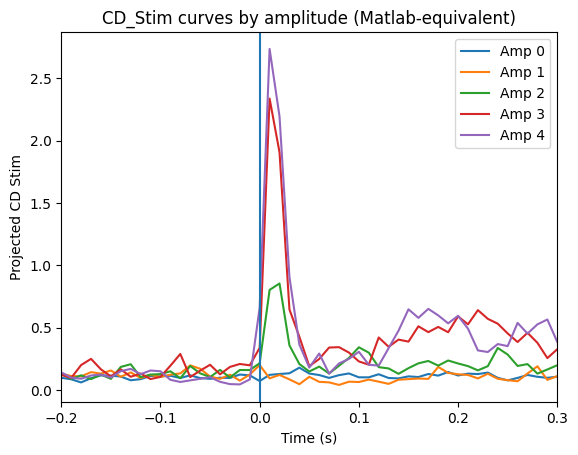

In [50]:
t_bef = 0.2
t_aft = 0.3
pt_bef = int(np.round(t_bef / Bin_size))
pt_aft = int(np.round(t_aft / Bin_size))
win = pt_bef + pt_aft + 1

def align_1d(signal, event_times):
    M = []
    for ev in event_times:
        c = int(np.round(ev / Bin_size))
        pt1 = c - pt_bef
        pt2 = c + pt_aft
        if pt1 < 0 or pt2 >= len(signal):
            continue
        M.append(signal[pt1:pt2+1])
    return np.stack(M, axis=0) if len(M) else np.zeros((0, win), dtype=signal.dtype)

CD_Stim_by_amp = {}
CD_Stim_distrib_by_amp = {}

# all amplitudes
amps_list = sorted(tr["whisker_stim_amplitude"].dropna().unique())

for Amp in amps_list:
    
    
    if Amp == 0:
        sel = tr["no_stim"].astype(bool) & tr["no_stim_time"].notna()
        ev_times = tr.loc[sel, "no_stim_time"].to_numpy()
    else:
        sel = (tr["whisker_stim_amplitude"] == Amp) & tr["whisker_stim_time"].notna()
        ev_times = tr.loc[sel, "whisker_stim_time"].to_numpy()

    M = align_1d(Projected_Act_CD_Stim, ev_times)
    
    CD_Stim_by_amp[Amp] = M.mean(axis=0) if M.shape[0] else np.zeros(win)
    

    if M.shape[0]:
        CD_Stim_distrib_by_amp[Amp] = np.max(M[:, 20:31], axis=1)
    else:
        CD_Stim_distrib_by_amp[Amp] = np.array([], dtype=float)

t_vect = np.linspace(-t_bef, t_aft, win)

plt.figure()
for Amp in range(0, 5):
    plt.plot(t_vect, CD_Stim_by_amp[Amp], label=f"Amp {Amp}")
plt.axvline(0)
plt.xlim([-t_bef, t_aft])
plt.xlabel("Time (s)")
plt.ylabel("Projected CD Stim")
plt.legend()
plt.title("CD_Stim curves by amplitude (Matlab-equivalent)")
plt.show()

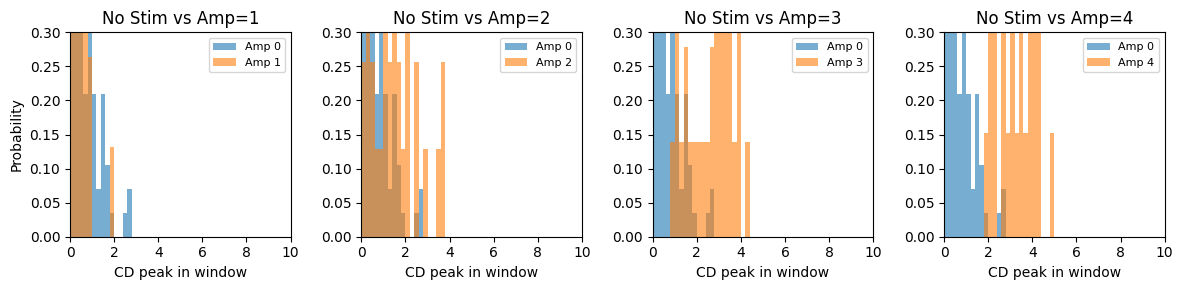

In [51]:
bin_width = 0.2
pairs = [(0,1), (0,2), (0,3), (0,4)]

plt.figure(figsize=(12, 3))
for i, (a0, a1) in enumerate(pairs, 1):
    plt.subplot(1,4,i)
    plt.hist(CD_Stim_distrib_by_amp[a0], bins=np.arange(0, 10+bin_width, bin_width), density=True, alpha=0.6, label=f"Amp {a0}")
    plt.hist(CD_Stim_distrib_by_amp[a1], bins=np.arange(0, 10+bin_width, bin_width), density=True, alpha=0.6, label=f"Amp {a1}")
    plt.xlim([0,10])
    plt.ylim([0,0.3])
    plt.title(f"No Stim vs Amp={a1}")
    if i == 1:
        plt.ylabel("Probability")
    plt.xlabel("CD peak in window")
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

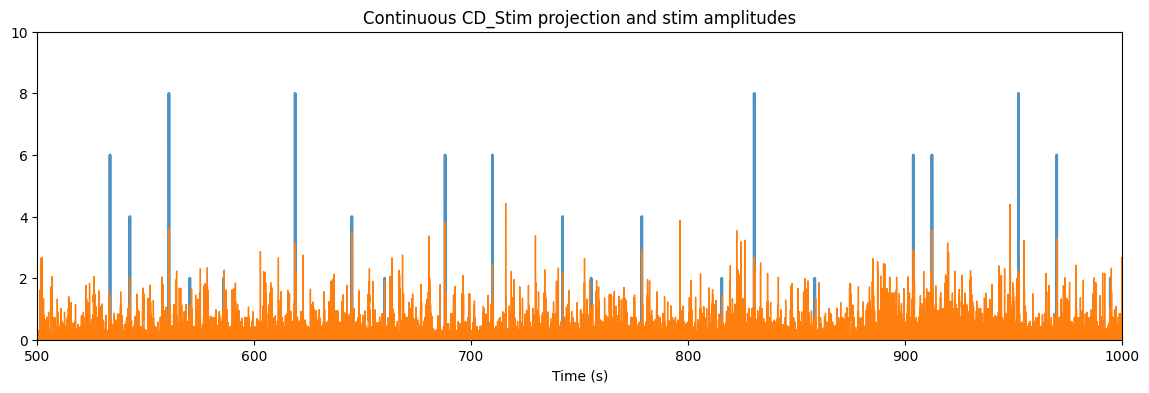

In [52]:
cont_t_vect = np.arange(len(Projected_Act_CD_Stim)) * Bin_size
Stim_Vect_Amp = np.zeros(len(Projected_Act_CD_Stim), dtype=float)

# only whisker stim events
sel = tr["whisker_stim_time"].notna()
ev_times = tr.loc[sel, "whisker_stim_time"].to_numpy()
amps = tr.loc[sel, "whisker_stim_amplitude"].to_numpy()

for ev, amp in zip(ev_times, amps):
    if amp != 0:
        pt_stim = int(np.round(ev / Bin_size))
        if 0 <= pt_stim < len(Stim_Vect_Amp):
            Stim_Vect_Amp[pt_stim] = amp
    else:
        print("Warning: Found no_stim event in whisker_stim_time.")

        
plt.figure(figsize=(14,4))
plt.plot(cont_t_vect, Stim_Vect_Amp * 2, linewidth=2, alpha=0.8)  # *2 pour visibilité
plt.plot(cont_t_vect, Projected_Act_CD_Stim, linewidth=1)
plt.xlim([500, 1000])
plt.ylim([0, 10])
plt.xlabel("Time (s)")
plt.title("Continuous CD_Stim projection and stim amplitudes")
plt.show()

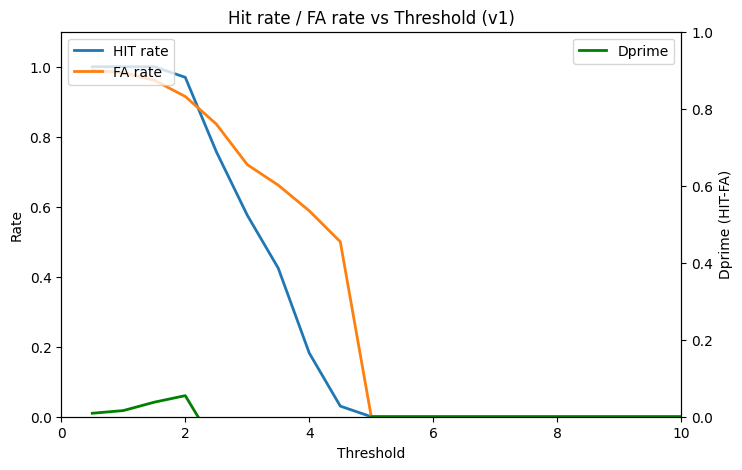

In [54]:
Thrs_Max = 10
Thrs_min = 0.5
Thrs_Step = 0.5
Thrs_vals = np.arange(Thrs_Max, Thrs_min - 1e-9, -Thrs_Step)

Time_Wind = 0.1  # seconds

# --- Event times (ABS)
Whisker_Stim_times_H = np.sort(tr.loc[(tr["whisker_stim_amplitude"] == 4) & tr["whisker_stim_time"].notna(), "whisker_stim_time"].to_numpy())

Whisker_Stim_times_C = np.sort(tr.loc[tr["whisker_stim_amplitude"].between(1, 4) & tr["whisker_stim_time"].notna(), "whisker_stim_time"].to_numpy())

HIT_rate = []
FA_rate = []

for thr in Thrs_vals:
    # HIT on amp 4 trials
    detected = []
    for ev in Whisker_Stim_times_H:
        pt1 = int(np.round(ev / Bin_size))
        pt2 = int(np.round((ev + Time_Wind) / Bin_size))
        if pt1 < 0 or pt1 >= len(Projected_Act_CD_Stim):
            continue
        pt2 = min(pt2, len(Projected_Act_CD_Stim) - 1)
        detected.append(np.max(Projected_Act_CD_Stim[pt1:pt2+1]) > thr)

    hit = np.mean(detected) if len(detected) else np.nan
    HIT_rate.append([thr, hit])

    # FA via peaks not preceded by a stim 1..4
    peaks, props = find_peaks(Projected_Act_CD_Stim, height=thr)
    peak_times = peaks * Bin_size

    false = []
    for pt in peak_times:
        dt = Whisker_Stim_times_C - pt
        explained = np.any((dt < 0) & (dt > -Time_Wind))
        false.append(0 if explained else 1)

    fa = np.sum(false) / len(false) if len(false) else 0.0
    FA_rate.append([thr, fa])

HIT_rate = np.array(HIT_rate, float)
FA_rate = np.array(FA_rate, float)

# "Dprime" = HIT - FA
hit_dp = HIT_rate[:, 1].copy()
fa_dp = FA_rate[:, 1].copy()
hit_dp[hit_dp == 0] = 0.001
hit_dp[hit_dp == 1] = 0.999
fa_dp[fa_dp == 0] = 0.001
fa_dp[fa_dp == 1] = 0.999
Dprime = hit_dp - fa_dp


plt.figure(figsize=(8, 5))
ax = plt.gca()

ax.plot(HIT_rate[:, 0], HIT_rate[:, 1], linewidth=2, label="HIT rate")
ax.plot(FA_rate[:, 0], FA_rate[:, 1], linewidth=2, label="FA rate")
ax.set_xlim([0, 10])
ax.set_ylim([0, 1.1])
ax.set_xlabel("Threshold")
ax.set_ylabel("Rate")

ax2 = ax.twinx()
ax2.plot(HIT_rate[:, 0], Dprime, linewidth=2, label="Dprime", color="green")
ax2.set_ylim([0, 1])
ax2.set_ylabel("Dprime (HIT-FA)")

ax.set_title("Hit rate / FA rate vs Threshold (v1)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()

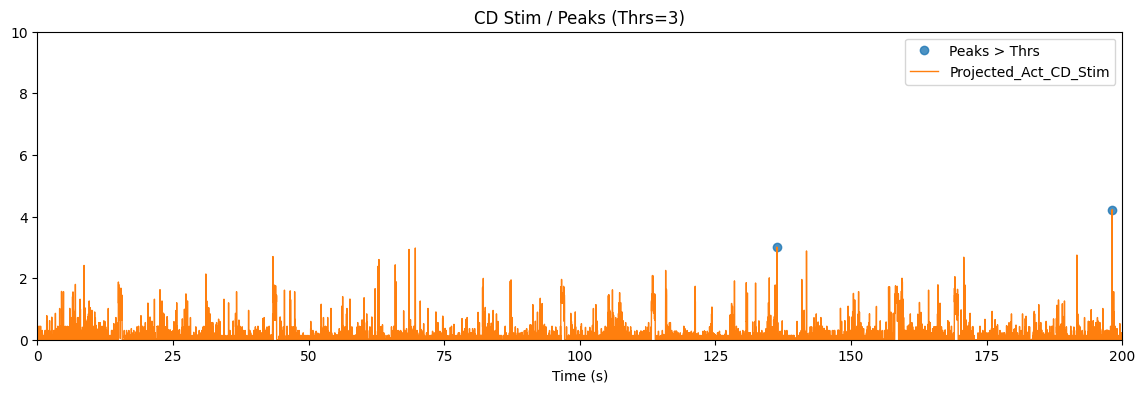

FA_rate (Thrs=3, no amp4 stim in previous 0.5s): 0.8391608391608392


In [ ]:
Thrs_i = 3

# Peaks above threshold
peaks, props = find_peaks(Projected_Act_CD_Stim, height=Thrs_i)
Peak_Amp = props["peak_heights"]
Peak_Times = peaks * Bin_size

plt.figure(figsize=(14, 4))
plt.plot(Peak_Times, Peak_Amp, "o", linewidth=2, alpha=0.8, label="Peaks > Thrs")
plt.plot(cont_t_vect, Projected_Act_CD_Stim, linewidth=1, label="Projected_Act_CD_Stim")
plt.xlim([0, 200])
plt.ylim([0, 10])
plt.xlabel("Time (s)")
plt.title("CD Stim / Peaks (Thrs=3)")
plt.legend()
plt.show()

# FA relative to amp 4 stim only, window = 0.5s (Matlab)
Whisker_Stim_times_H = np.sort(
    tr.loc[(tr["whisker_stim_amplitude"] == 4) & tr["whisker_stim_time"].notna(), "whisker_stim_time"].to_numpy()
)

False_Stim = []
for pt in Peak_Times:
    dt = Whisker_Stim_times_H - pt
    explained = np.any((dt < 0) & (dt > -0.5))
    False_Stim.append(0 if explained else 1)

FA_rate_at_3 = np.sum(False_Stim) / len(False_Stim) if len(False_Stim) else 0.0
print("FA_rate (Thrs=3, no amp4 stim in previous 0.5s):", FA_rate_at_3)

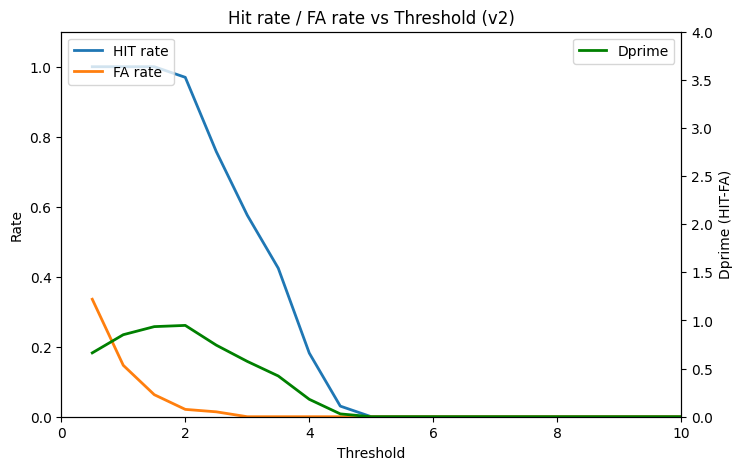

In [59]:
Thrs_Max = 10
Thrs_min = 0.5
Thrs_Step = 0.5
Thrs_vals = np.arange(Thrs_Max, Thrs_min - 1e-9, -Thrs_Step)

Time_Wind = 0.1

# HIT (amp 4)
Whisker_Stim_times_H = np.sort(tr.loc[(tr["whisker_stim_amplitude"] == 4) & tr["whisker_stim_time"].notna(), "whisker_stim_time"].to_numpy())

# CATCH
sel_catch = tr["no_stim"].astype(bool) & tr["no_stim_time"].notna()
no_stim_t = tr.loc[sel_catch, "no_stim_time"].to_numpy()

if len(no_stim_t) and np.nanmedian(no_stim_t) < 20:
    Catch_times = np.sort((tr.loc[sel_catch, "start_time"] + tr.loc[sel_catch, "no_stim_time"]).to_numpy())
else:
    Catch_times = np.sort(no_stim_t)

HIT_rate = []
FA_rate = []

for thr in Thrs_vals:
    # HIT amp 4
    Detected_Stim = []
    for ev in Whisker_Stim_times_H:
        pt1 = int(np.round(ev / Bin_size))
        pt2 = int(np.round((ev + Time_Wind) / Bin_size))
        if pt1 < 0 or pt1 >= len(Projected_Act_CD_Stim):
            continue
        pt2 = min(pt2, len(Projected_Act_CD_Stim) - 1)
        Detected_Stim.append(np.max(Projected_Act_CD_Stim[pt1:pt2+1]) > thr)

    hit = np.mean(Detected_Stim) if len(Detected_Stim) else np.nan
    HIT_rate.append([thr, hit])

    # FA
    False_Stim = []
    for ev in Catch_times:
        pt1 = int(np.round(ev / Bin_size))
        pt2 = int(np.round((ev + Time_Wind) / Bin_size))
        if pt1 < 0 or pt1 >= len(Projected_Act_CD_Stim):
            continue
        pt2 = min(pt2, len(Projected_Act_CD_Stim) - 1)
        False_Stim.append(np.max(Projected_Act_CD_Stim[pt1:pt2+1]) > thr)

    fa = np.mean(False_Stim) if len(False_Stim) else np.nan
    FA_rate.append([thr, fa])

HIT_rate = np.array(HIT_rate, float)
FA_rate = np.array(FA_rate, float)

# "Dprime" = HIT - FA
hit_dp = HIT_rate[:, 1].copy()
fa_dp = FA_rate[:, 1].copy()
hit_dp[hit_dp == 0] = 0.001
hit_dp[hit_dp == 1] = 0.999
fa_dp[fa_dp == 0] = 0.001
fa_dp[fa_dp == 1] = 0.999
Dprime = hit_dp - fa_dp


plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.plot(HIT_rate[:, 0], HIT_rate[:, 1], linewidth=2, label="HIT rate")
ax.plot(FA_rate[:, 0], FA_rate[:, 1], linewidth=2, label="FA rate")
ax.set_xlim([0, 10])
ax.set_ylim([0, 1.1])
ax.set_xlabel("Threshold")
ax.set_ylabel("Rate")

ax2 = ax.twinx()
ax2.plot(HIT_rate[:, 0], Dprime, linewidth=2, label="Dprime", color="green")
ax2.set_ylim([0, 4])
ax2.set_ylabel("Dprime (HIT-FA)")

ax.set_title("Hit rate / FA rate vs Threshold (v2)")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()

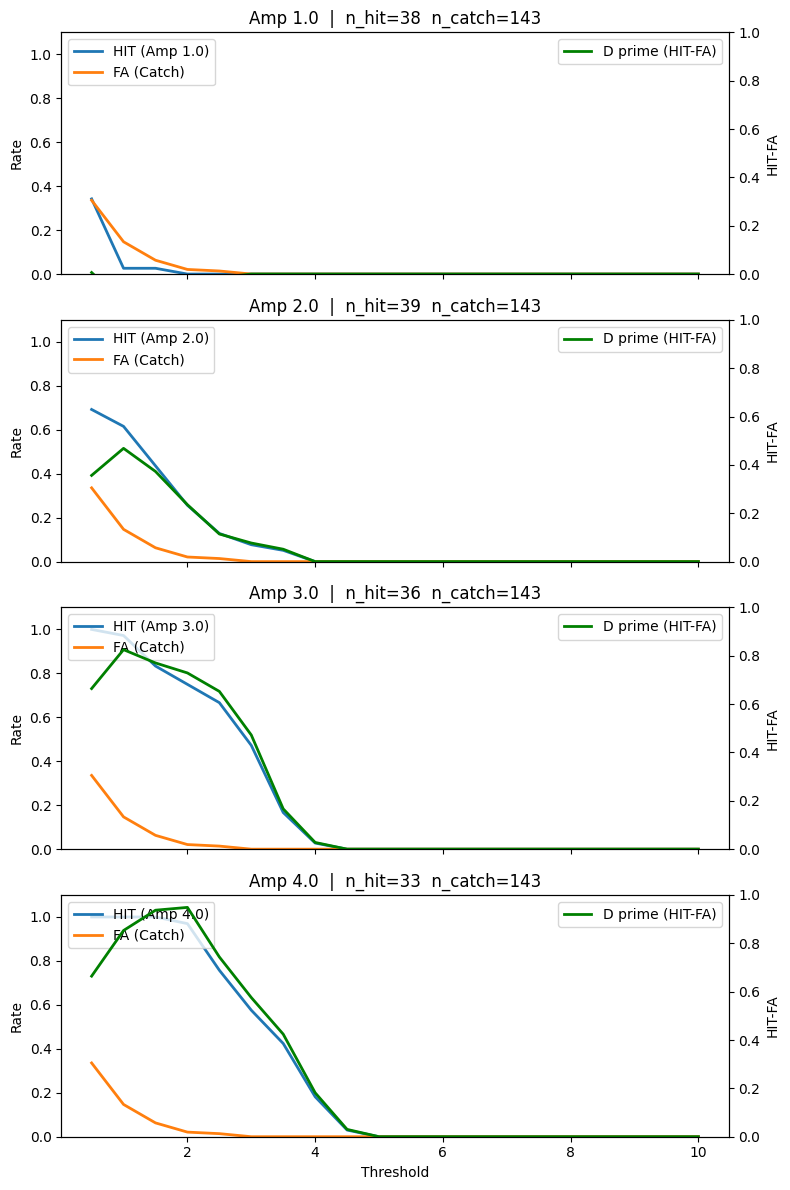

In [64]:
Thrs_vals = np.arange(10, 0.5 - 1e-9, -0.5)
Time_Wind = 0.1 

# Catch
sel_catch = tr["no_stim"].astype(bool) & tr["no_stim_time"].notna()
no_stim_t = tr.loc[sel_catch, "no_stim_time"].to_numpy()


def rate_over_events(signal, event_times, thr, bin_size, time_wind):
    det = []
    L = len(signal)
    for ev in event_times:
        pt1 = int(np.round(ev / bin_size))
        pt2 = int(np.round((ev + time_wind) / bin_size))
        if pt1 < 0 or pt1 >= L:
            continue
        pt2 = min(pt2, L - 1)
        det.append(np.max(signal[pt1:pt2+1]) > thr)
    return (np.mean(det), len(det)) if len(det) else (np.nan, 0)

# FA
FA = np.zeros(len(Thrs_vals), dtype=float)
FA_n = np.zeros(len(Thrs_vals), dtype=int)

for i, thr in enumerate(Thrs_vals):
    FA[i], FA_n[i] = rate_over_events(Projected_Act_CD_Stim, Catch_times, thr, Bin_size, Time_Wind)

# all amp
amps_list = sorted(tr["whisker_stim_amplitude"].dropna().unique())
amps_list = [a for a in amps_list if a != 0]

n = len(amps_list)
fig, axes = plt.subplots(n, 1, figsize=(8, 3*n), sharex=True)

if n == 1:
    axes = [axes]

for ax, amp in zip(axes, amps_list):
    sel_hit = (tr["whisker_stim_amplitude"] == amp) & tr["whisker_stim_time"].notna()
    Stim_times = np.sort(tr.loc[sel_hit, "whisker_stim_time"].to_numpy())

    HIT = np.zeros(len(Thrs_vals), dtype=float)
    HIT_n = np.zeros(len(Thrs_vals), dtype=int)

    for i, thr in enumerate(Thrs_vals):
        HIT[i], HIT_n[i] = rate_over_events(Projected_Act_CD_Stim, Stim_times, thr, Bin_size, Time_Wind)

    D = HIT - FA

    ax.plot(Thrs_vals, HIT, linewidth=2, label=f"HIT (Amp {amp})")
    ax.plot(Thrs_vals, FA, linewidth=2, label="FA (Catch)")
    ax2 = ax.twinx()
    ax2.plot(Thrs_vals, D, linewidth=2, label="D prime (HIT-FA)", color="green")

    ax.set_ylim(0, 1.1)
    ax2.set_ylim(0, 1)
    ax.set_ylabel("Rate")
    ax2.set_ylabel("HIT-FA")
    ax.set_title(f"Amp {amp}  |  n_hit={len(Stim_times)}  n_catch={len(Catch_times)}")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

axes[-1].set_xlabel("Threshold")
plt.tight_layout()
plt.show()